In [1]:
# Setting up the file path
import os
os.chdir('..')

In [2]:
# Importing packages
import torch
import matplotlib.pyplot as plt
from RL4CRN.distributions.categorical import MultiVariateCategorical

torch.Size([10000, 2, 3])


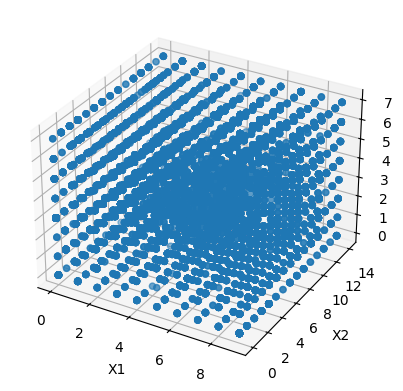

In [3]:
# Create a batch of multivariate categorical distributions with 3 variables using logits
batch_size = 2
arities = torch.tensor([10, 15, 8]) # 3 variables with arities K1=10, K2=15, K3=8  -> total states = 10*15*8
Ktot = int(arities.prod())
logits = torch.randn(batch_size, Ktot)    # one joint per batch item
distributions = MultiVariateCategorical(arities=arities, logits=logits)
x = distributions.sample((10000,))               # (batch_size, 3)
lp = distributions.log_prob(x)            # (batch_size,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
print(x.shape)
ax.scatter(x[:,:,0], x[:,:,1], x[:,:,2])
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
plt.show()

In [4]:
# Create a batch of multivariate categorical distributions with 3 variables using values and probs
values = [torch.tensor([0, 10, 20, 30, 40, 50, 60, 70, 80, 90]),      
          torch.tensor([.5, .7, .9, 1.1, 1.3, 1.5, 1.8, 1.9, 2., 3.1, 4.5, 5., 5.2, 5.5, 6.]),     
          torch.tensor([0, 1, 2, 3, 4, 5, 6, 7])]         
probs = torch.ones(torch.prod(torch.tensor([values[i].shape[0] for i in range(len(values))]))); probs /= probs.sum()
# distributions = MultiVariateCategorical(values=values, probs=probs)
distributions = MultiVariateCategorical(values=values, logits=logits)

In [5]:
x  = distributions.sample((10000,))               # (batch_size, 3)
lp = distributions.log_prob(x)            # (batch_size,)

/local0/home/mfilo/git/CRN-GenerativeAI/RL4CRN/distributions/categorical.py:107: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  j = torch.searchsorted(vi, xi)


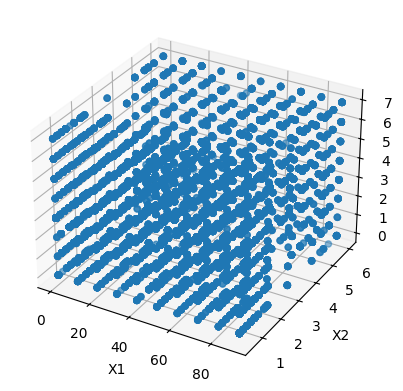

In [6]:
# plot in 3D the samples
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:,:,0], x[:,:,1], x[:,:,2])
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
plt.show()
